In [1]:
import numpy as np
import pandas as pd
import scipy

import random

from src.simulation.domain.model import construct_well, h_lim, betta_G_lim
from src.simulation.service_layer.services import get_dict_for_data, build_plot, PlotData, Scale
from src.simulation.domain.meter import Meter, add_noise
from src.identification.domain.model import ident_values, identificate, get_data_by_slices, identificate_regul, get_res_dict_for_ident
from src.identification.service_layer.services import calc_error_by_series, calc_rsd_by_series

In [2]:
# Начальные условия
M_q = 0.5
epsilon = 0.00001
K_NUMBERS = 45000  # Количество точек моделирования
dt = 0.0001  # Суток

w_program = {2: 1.065556, 3: 0.9335, 3.7: 1}

well = construct_well(agzu_on=True, p_L_change_on=True)
well.set_w_program(w_program)


df = well.simulate(K_NUMBERS, dt, M_q, epsilon, get_dict_for_data())
df = pd.DataFrame(df)

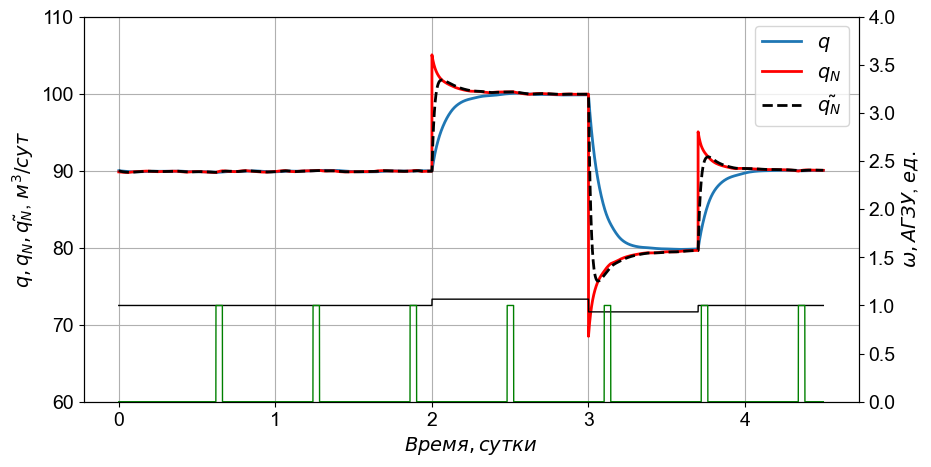

In [3]:
plot_data = [
             {'data': (
                PlotData(df['q'], '', 2, 'q'),
                PlotData(df['q_N'], 'r', 2, 'q_N'),
                PlotData(df['q_L'], 'k--', 2, '\\tilde{q_N}'),
              ), 'x': df['x'], 'y_scale': Scale(min=60, max=110), 'dt': dt, 'mu': 'м^3/сут'},
             {'data': (
               PlotData(df['u'], 'k', 1, '\omega'),
               PlotData(df['agzu'], 'g', 1, 'АГЗУ'),
              ), 'x': df['x'], 'y_scale': Scale(min=0, max=4), 'dt': dt, 'mu': 'ед.'},
            ]

plot = build_plot(plot_data)
plot.show()

In [4]:
#df.to_excel("model_output.xlsx")

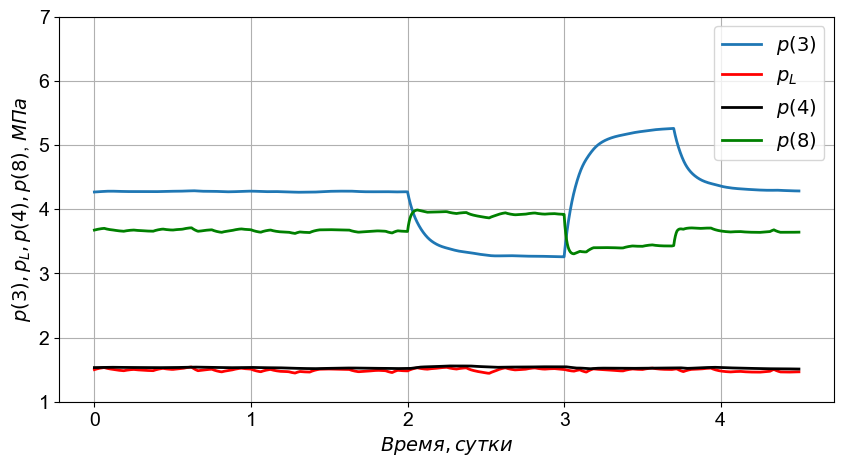

In [5]:
plot_data = [
            {'data': (
              PlotData(df['p_3'], '', 2, 'p(3)'),
              PlotData(df['p_L'], 'r', 2, 'p_L'),
              PlotData(df['p_4'], 'k', 2, 'p(4)'),
              PlotData(df['p_8'], 'g', 2, 'p(8)'),
              ), 'x': df['x'], 'y_scale': Scale(min=1, max=7), 'dt': dt, 'mu': 'МПа'},

]


plot = build_plot(plot_data)
plot.show()

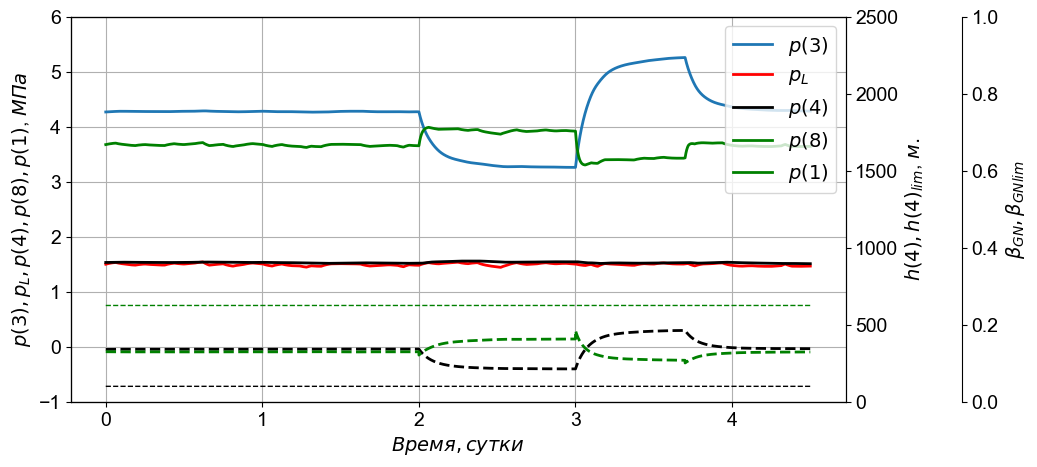

In [6]:
plot_data = [
            {'data': (
              PlotData(df['p_3'], '', 2, 'p(3)'),
              PlotData(df['p_L'], 'r', 2, 'p_L'),
              PlotData(df['p_4'], 'k', 2, 'p(4)'),
              PlotData(df['p_8'], 'g', 2, 'p(8)'),
              PlotData(df['p_1'], 'g', 2, 'p(1)'),
              ), 'x': df['x'], 'y_scale': Scale(min=-1, max=6), 'dt': dt, 'mu': 'МПа'},
            {'data': (
                PlotData(df['h_4'], 'k--', 2, 'h(4)'),
                PlotData(pd.Series([h_lim]*K_NUMBERS), 'k--', 1, 'h(4)_{lim}')
              ), 'x': df['x'], 'y_scale': Scale(min=0, max=2500), 'dt': dt, 'mu': 'м.'},
            {'data': (
                PlotData(df['betta_GN'], 'g--', 2, '\\beta_{GN}'),
                PlotData(pd.Series([betta_G_lim]*K_NUMBERS), 'g--', 1, '\\beta_{GNlim}')
              ), 'x': df['x'], 'y_scale':  Scale(min=0, max=1), 'dt': dt},
]


plot = build_plot(plot_data)
plot.show()

In [7]:
meter = Meter(dt)
meter.noise_enable = True
meter.noise_amplitude = 0.03
ident_dt, ident_k, df_ident = meter.measure(df, quant_step=0.05, denominator = 35)

In [8]:
#df_ident.to_excel("model_measure.xlsx")

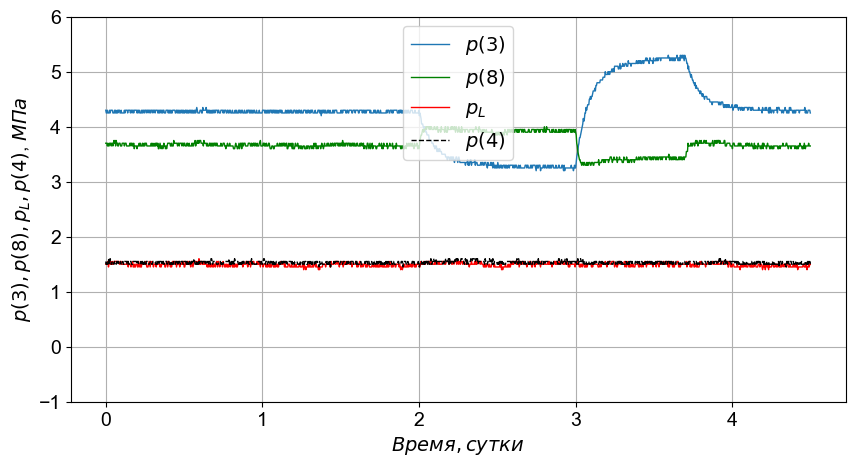

In [9]:
plot_data = [
            {'data': (
              PlotData(df_ident['p_3'], '', 1, 'p(3)'),
              PlotData(df_ident['p_8'], 'g', 1, 'p(8)'),
              PlotData(df_ident['p_L'], 'r', 1, 'p_L'),
              PlotData(df_ident['p_4'], 'k--', 1, 'p(4)'),
              ), 'x': df_ident['x'], 'y_scale': Scale(min=-1, max=6), 'dt': dt, 'mu': 'МПа'},
            ]

plot = build_plot(plot_data)
plot.show()

In [10]:
# Устойчивость идентификации

quant_step_list = list(map(float, (np.linspace(0.001, 0.2, num=50))))
denominator_list = list(map(int, (np.linspace(7, 49, num=50))))
experiment_num_max = 250

res = {'p_R': np.zeros((len(quant_step_list), experiment_num_max)),
       'r_1': np.zeros((len(quant_step_list), experiment_num_max)),
       'r_2': np.zeros((len(quant_step_list), experiment_num_max)),
       }

res_regul = {'p_R': np.zeros((len(quant_step_list), experiment_num_max)),
             'r_1': np.zeros((len(quant_step_list), experiment_num_max)),
             'r_2': np.zeros((len(quant_step_list), experiment_num_max)),
             }

meter = Meter(dt)
meter.noise_enable = False
meter.noise_amplitude = 0.03


def identificate_both(res, res_regul, quant_step, denominator):

    ident_dt, ident_k, df_ident = meter.measure(df, quant_step=quant_step, denominator=denominator)

    calc_df = ident_values(ident_k, ident_dt, df_ident, well, filter_name='aperiodic')
    b, _ = identificate(calc_df, ident_k)

    s_times = [(0, 1)]
    calc_df_static = get_data_by_slices(calc_df, ident_dt, s_times)

    regul_times = [(1, 4.5)]
    calc_df_regul = get_data_by_slices(calc_df, ident_dt, regul_times)
    b_regul = identificate_regul(calc_df_regul, calc_df_static, well.reservoir.v_r, m2=1, m3=3*ident_k)

    res['p_R'][i, experiment_num] = b[0]
    res['r_1'][i, experiment_num] = b[1]
    res['r_2'][i, experiment_num] = b[2]

    res_regul['p_R'][i, experiment_num] = b_regul[0][0]
    res_regul['r_1'][i, experiment_num] = b_regul[1][0]
    res_regul['r_2'][i, experiment_num] = b_regul[2][0]

    return calc_df, df_ident


for i, quant_step in enumerate(quant_step_list):
    denominator = denominator_list[i]
    for experiment_num in range(experiment_num_max):
      calc_df, df_ident = identificate_both(res, res_regul, quant_step, denominator)


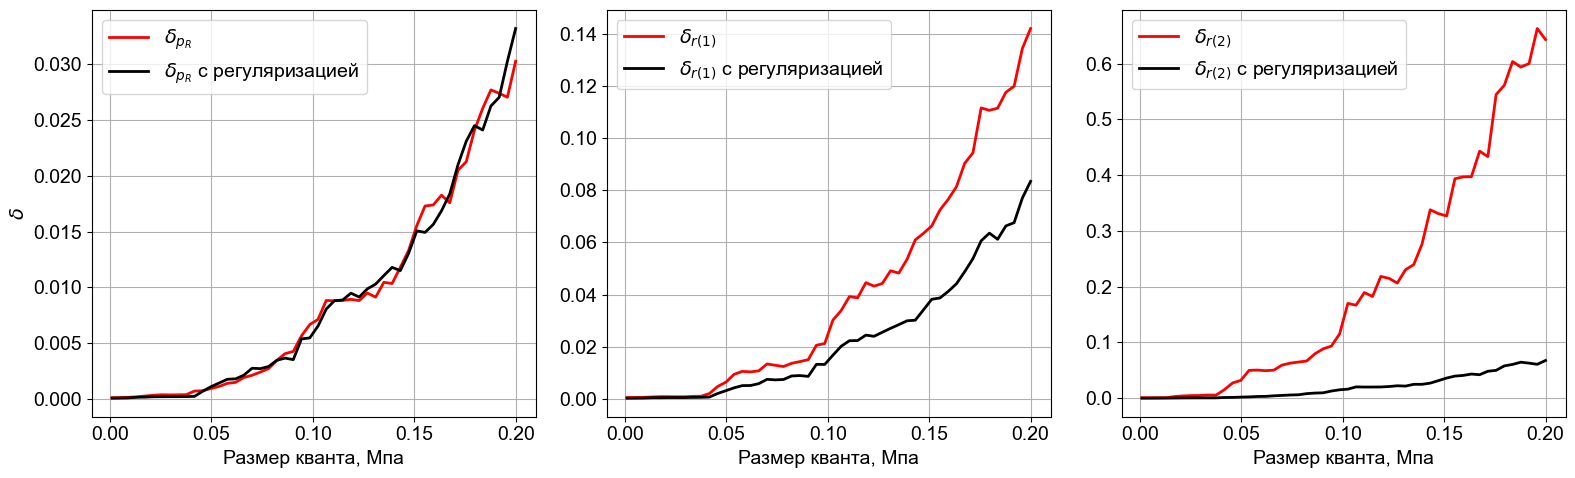

In [26]:
from matplotlib import pyplot as plt
from scipy.signal import savgol_filter
from src.helpers import filter_data


denominator_list = list(map(int, (np.linspace(1, 7, num=100))))
# Визуализация
plt.figure(figsize=(16, 5))

# График давления
plt.subplot(1, 3, 1)
plt.plot(quant_step_list, filter_data(calc_rsd_by_series(res['p_R'], well.reservoir.p_R), 'aperiodic', 1, 25), 'r', lw=2, label='$\delta_{p_R}$')
plt.plot(quant_step_list, filter_data(calc_rsd_by_series(res_regul['p_R'], well.reservoir.p_R), 'aperiodic', 1, 25), 'k', label='$\delta_{p_R}$ с регуляризацией', lw=2)
plt.xlabel('Размер кванта, Мпа')
plt.ylabel('$\delta$')
plt.legend()
plt.grid()


# График НЧ шума
plt.subplot(1, 3, 2)
plt.plot(quant_step_list, filter_data(calc_rsd_by_series(res['r_1'], well.reservoir.r_1), 'aperiodic', 1, 25), label='$\delta_{r(1)}$', color='r', lw=2)
plt.plot(quant_step_list, filter_data(calc_rsd_by_series(res_regul['r_1'], well.reservoir.r_1), 'aperiodic', 1, 25), label='$\delta_{r(1)}$ с регуляризацией', color='k', lw=2)
plt.xlabel('Размер кванта, Мпа')
plt.legend()
plt.grid()
#plt.ylim(0, 0.8)

# График ВЧ шума
plt.subplot(1, 3, 3)
plt.plot(quant_step_list, filter_data(calc_rsd_by_series(res['r_2'], well.reservoir.r_2), 'aperiodic', 1, 25), 'r', label='$\delta_{r(2)}$', lw=2)
plt.plot(quant_step_list, filter_data(calc_rsd_by_series(res_regul['r_2'], well.reservoir.r_2), 'aperiodic', 1, 25), 'k', label='$\delta_{r(2)}$ с регуляризацией', lw=2)
plt.xlabel('Размер кванта, Мпа')
plt.legend()
plt.grid()
#plt.ylim(0, 0.8)


plt.tight_layout()
plt.show()